Loading log: logs/pid_log_20250915_105450.csv


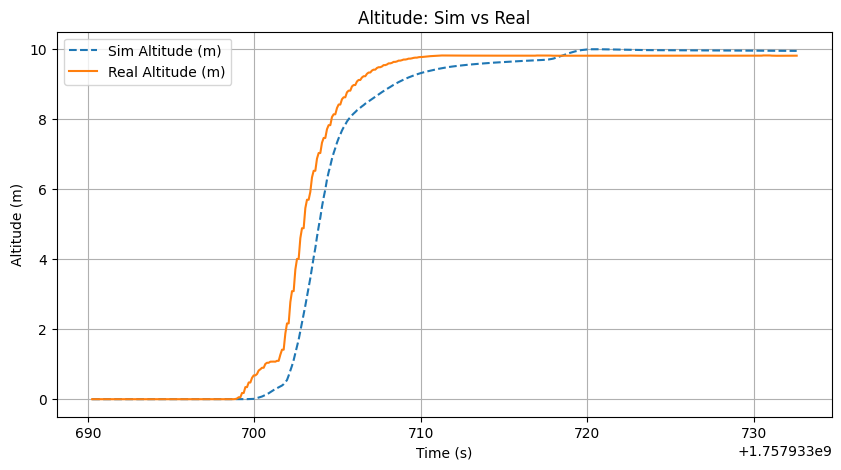

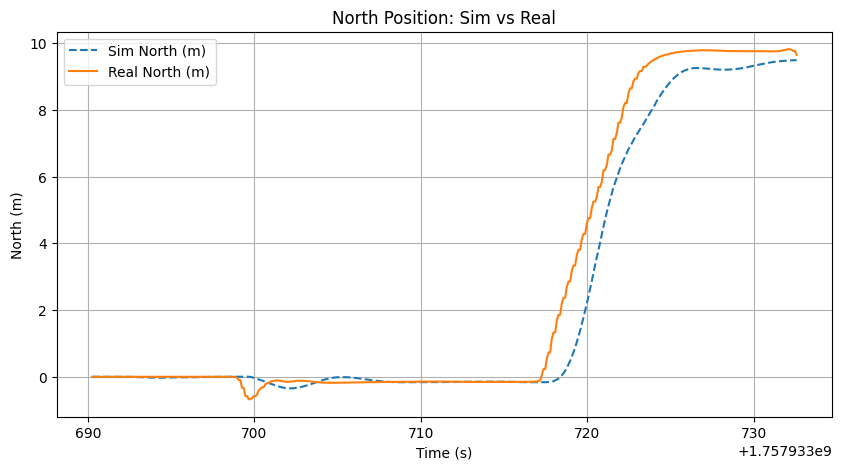

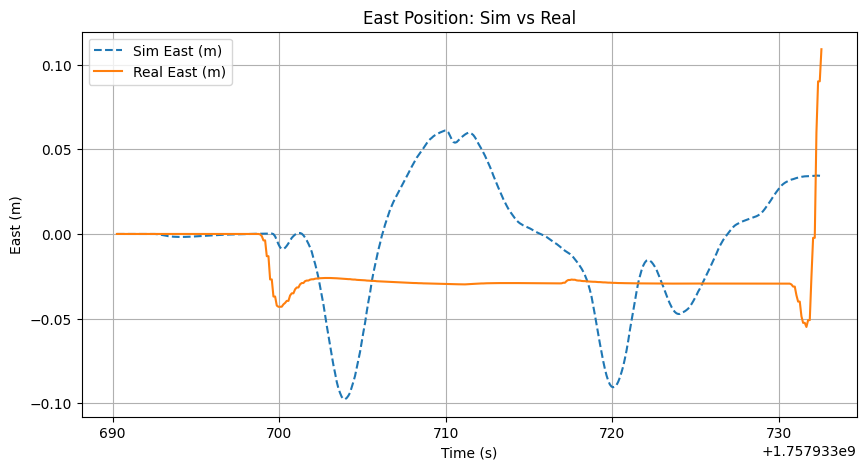

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import math

# --- Load the latest log automatically ---
log_dir = "logs"
log_files = sorted([f for f in os.listdir(log_dir) if f.endswith(".csv")])
if not log_files:
    raise FileNotFoundError("No CSV logs found in logs/ folder.")

log_file = os.path.join(log_dir, log_files[-1])
print(f"Loading log: {log_file}")

df = pd.read_csv(log_file)
df["time"] = df["time"].astype(float)

# --- Convert lat/lon to meters relative to first point ---
def latlon_to_meters(lat0, lon0, lat, lon):
    R = 6371000.0  # Earth radius in meters
    dlat = (lat - lat0) * math.pi / 180.0
    dlon = (lon - lon0) * math.pi / 180.0
    avg_lat = (lat + lat0) / 2.0 * math.pi / 180.0
    north = dlat * R
    east = dlon * R * math.cos(avg_lat)
    return north, east

# Use first row as reference
lat0_sim, lon0_sim = df["sim_lat"].iloc[0], df["sim_lon"].iloc[0]
lat0_real, lon0_real = df["lat"].iloc[0], df["lon"].iloc[0]

north_sim, east_sim = zip(*[latlon_to_meters(lat0_sim, lon0_sim, lat, lon) 
                            for lat, lon in zip(df["sim_lat"], df["sim_lon"])])
north_real, east_real = zip(*[latlon_to_meters(lat0_real, lon0_real, lat, lon) 
                              for lat, lon in zip(df["lat"], df["lon"])])

# --- Altitude: Sim vs Real ---
plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["sim_alt"], label="Sim Altitude (m)", linestyle="--")
plt.plot(df["time"], df["alt"], label="Real Altitude (m)")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.title("Altitude: Sim vs Real")
plt.legend()
plt.grid()
plt.show()

# --- North Position: Sim vs Real ---
plt.figure(figsize=(10, 5))
plt.plot(df["time"], north_sim, label="Sim North (m)", linestyle="--")
plt.plot(df["time"], north_real, label="Real North (m)")
plt.xlabel("Time (s)")
plt.ylabel("North (m)")
plt.title("North Position: Sim vs Real")
plt.legend()
plt.grid()
plt.show()

# --- East Position: Sim vs Real ---
plt.figure(figsize=(10, 5))
plt.plot(df["time"], east_sim, label="Sim East (m)", linestyle="--")
plt.plot(df["time"], east_real, label="Real East (m)")
plt.xlabel("Time (s)")
plt.ylabel("East (m)")
plt.title("East Position: Sim vs Real")
plt.legend()
plt.grid()
plt.show()
